In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from cryojax.ndimage import LowpassFilter
from cryospax import RelionParticleDataset, RelionParticleParameterFile

import cryojax_eo as cxeo

/tmp/ipykernel_93804/1323388880.py:3: FutureWarning: Submodule `cryojax.dataset` is deprecated and has been moved to the library `cryospax` (https://github.com/michael-0brien/cryospax). `cryojax.dataset` will be removed in cryoJAX 0.6.0.
  from cryojax.dataset import RelionParticleParameterFile, RelionParticleDataset


# Let's load the config file

In [3]:
config = cxeo.load_config("./config_data_simulation.yaml", config_mode="data simulation")

config.noise_snr

0.1

The image generation can be run from the command line as:

`simulate_data --config config_data_simulation.yaml`

if this fails, make sure your virtual environment is activated. This command simply runs the following function

In [4]:
cxeo.dataset.simulate_relion_dataset(config)

/mnt/home/dsilvasanchez/miniforge3/envs/ens_opt_cuda_forge/lib/python3.12/site-packages/equinox/_module/_module.py:549: FutureWarning: `BasicImageConfig.coordinate_grid_in_pixels` has been deprecated and will be removed in cryoJAX 0.6.0. Instead, make the appropriate call to `BasicImageConfig.get_coordinate_grid`.
  out = super().__getattribute__(name)


# Visualize the images!

In [ ]:
stack_dataset = RelionParticleDataset(
    RelionParticleParameterFile(
        path_to_starfile=config.path_to_starfile,
        mode="r",
        options=dict(loads_envelope=False),
    ),
    path_to_relion_project=config.path_to_relion_project,
    mode="r",
)

In [6]:
lowpass_filter = LowpassFilter(
    stack_dataset[0]["parameters"]["image_config"].frequency_grid_in_pixels,
    frequency_cutoff_fraction=0.7,
)

/mnt/home/dsilvasanchez/miniforge3/envs/ens_opt_cuda_forge/lib/python3.12/site-packages/equinox/_module/_module.py:549: FutureWarning: `BasicImageConfig.frequency_grid_in_pixels` has been deprecated and will be removed in cryoJAX 0.6.0. Instead, make the appropriate call to `BasicImageConfig.get_frequency_grid`.
  out = super().__getattribute__(name)


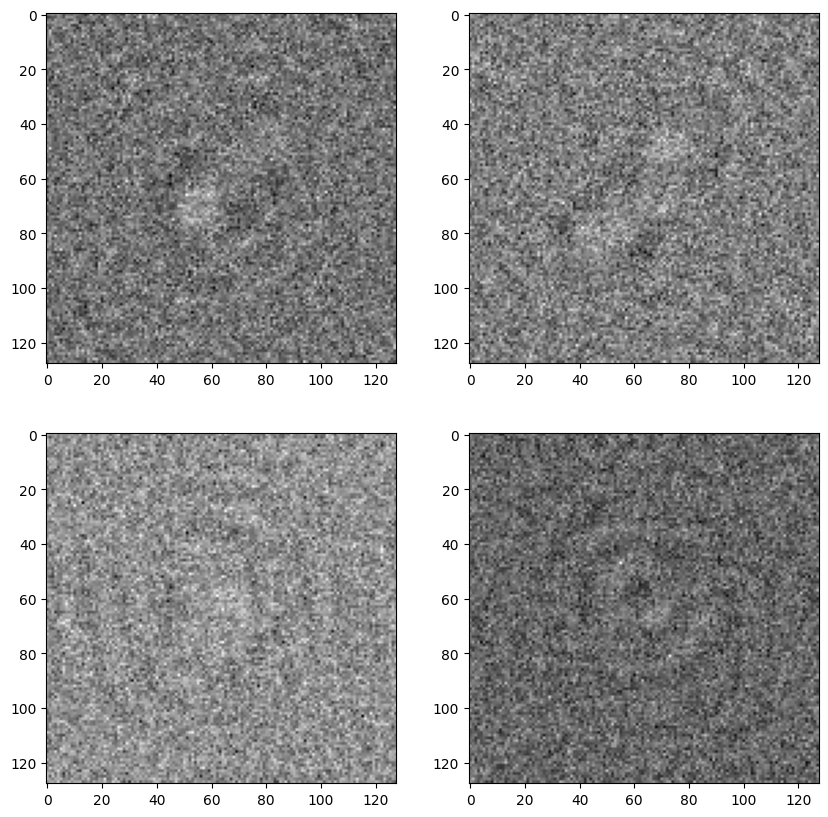

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

images = stack_dataset[0:4]["images"]
# images = irfftn(lowpass_filter(rfftn(images)))

for i in range(4):
    ax.flatten()[i].imshow(images[i], cmap="gray")

## Metadata

Information about the ensemble and other parameters is saved to a metadata file

In [8]:
metadata = np.load("tutorial_data/metadata.npz")

metadata.files

['snr_per_image', 'ensemble_indices_per_image']

In [9]:
metadata["ensemble_indices_per_image"]

array([0, 0, 1, ..., 0, 1, 0], dtype=int32)

In [10]:
weight_0 = np.isclose(metadata["ensemble_indices_per_image"], 0).mean()
weight_1 = np.isclose(metadata["ensemble_indices_per_image"], 1).mean()

weight_0, weight_1

(0.6912, 0.3088)